In [1]:
from dataprep import *
from dataviz import plots
import utils

In [ ]:
dvf_tot = get_dvf_df(is_save=True)

In [2]:
dvf_clean = get_dvf_clean(is_save=True)

Price mean: 4 702,16 €/m²      
Median: 4 538,46 €/m²      
Mode: 4 451,67 €/m²


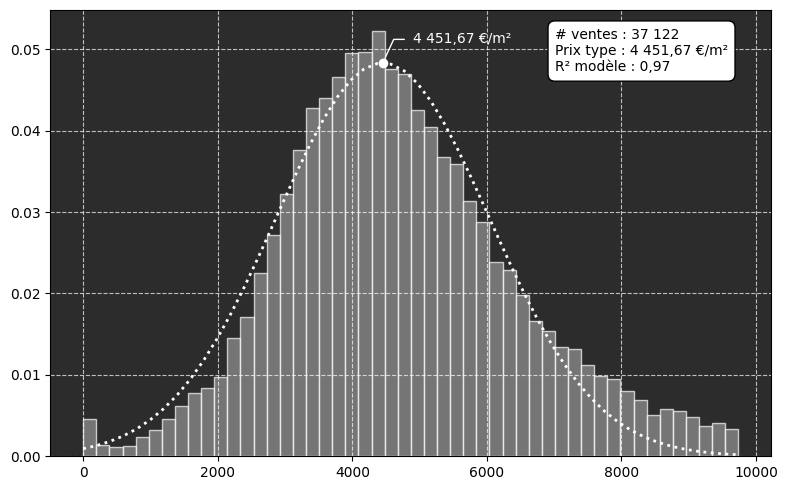

In [3]:
df_density = dvf_clean.loc[(dvf_clean["Code INSEE"]== "6088")]

print(f"Price mean: {utils.reformat_number(df_density['Prix au m2'].mean())} €/m²\
      \nMedian: {utils.reformat_number(df_density['Prix au m2'].median())} €/m²\
      \nMode: {utils.reformat_number(utils.gauss_mode(df_density['Prix au m2'], bins=50))} €/m²")

plots.normal_density(df=df_density,col="Prix au m2")


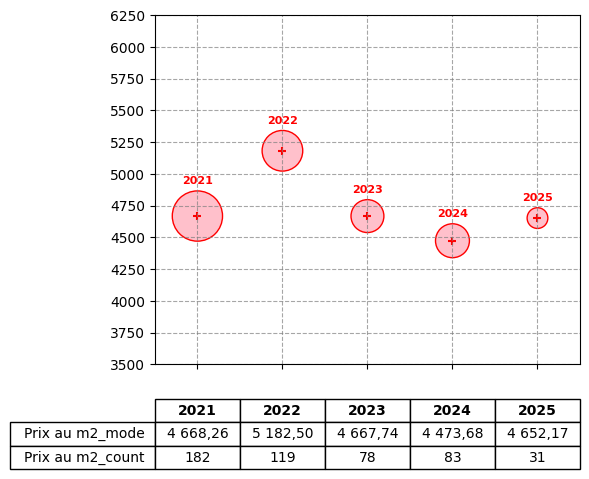

In [4]:
# dvf_scatter = dvf_clean.loc[(dvf_clean["Code departement"]== "69") & (dvf_clean["Commune"].str.match(r"LYON \dE*"))]
dvf_scatter = dvf_clean.loc[(dvf_clean["Commune"] == "MONTMORENCY") & (dvf_clean["Code type local"] == 1)]
plots.bubble_scatter(dvf_scatter, col_x="Annee", col_y="Prix au m2", method="mode")

In [8]:
dvf_communes = dvf.get_dvf_communes(is_save=True)
dvf_communes_clean = dvf.clean_communes(dvf_communes)

In [6]:
filosofi_df = get_filosofi_df(is_save=True)
fil_communes_df = melodi_filosofi.filter_on_communes(filosofi_df)

fil_communes_wide = utils.wide_data(fil_communes_df)
fil_communes_narrow = utils.narrow_data(fil_communes_df)

In [9]:
min_year = dvf_communes_clean["Annee"].min()

ipc_df = get_ipc_df(min_year, is_save=True)
rates_df = webstat.get_mortgage_rates_df(min_year, is_save=True)

socio_eco_df = rates_df.merge(ipc_df, on="Annee", how="outer")

In [10]:
socio_eco_df

,Annee,Taux_immo,Ind_prix
0,2021,1.276229,1744.0
1,2022,1.466823,1777.0
2,2023,3.066235,1673.0
3,2024,3.632137,1705.0
4,2025,3.126406,1718.0
5,2026,NaN,1717.0
